# Similarity Approach - Results Analysis

Analysis of the **operator action recommendation** results from the similarity-based approach.  
Results loaded from `operator_action_recommendations_by_episode.xlsx` (one sheet per episode, **33 test episodes**).

### Key Questions
1. **PV similarity saturation** – PV values are nearly identical (mean ~0.999), so similarity scores are dominated by ROC & direction components.
2. **Same-minute redundancy** – Multiple actual operator actions within the same minute share the same PV context → identical recommendations.
3. **Overall accuracy** – Tag match, direction match, magnitude match across all ranks.
4. **Per-episode breakdown** – Which episodes are well-predicted and which are not?

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ---------- Load all sheets from the results Excel file ----------
os.chdir('/home/h604827/ControlActions')
results_path = 'RESULTS/similarity_test_results/no_deviation_episodes/operator_action_recommendations_by_episode.xlsx'
xls = pd.ExcelFile(results_path)

all_sheets = []
for sheet in xls.sheet_names:
    df = pd.read_excel(results_path, sheet_name=sheet)
    all_sheets.append(df)

results_df = pd.concat(all_sheets, ignore_index=True)
print(f"Loaded {len(xls.sheet_names)} episode sheets")
print(f"Total rows: {len(results_df)}  |  Episodes: {results_df['episode_id'].nunique()}")
print(f"Row types: {results_df['row_type'].value_counts().to_dict()}")
print()

# Separate actual and recommended rows
actuals_df = results_df[results_df['row_type'] == 'actual'].copy()
recs_df = results_df[results_df['row_type'] == 'recommended'].copy()

print(f"Actual actions: {len(actuals_df)}  |  Recommendations: {len(recs_df)}  |  Recs per action: {len(recs_df)/len(actuals_df):.1f}")
results_df.head(4)

Loaded 33 episode sheets
Total rows: 2220  |  Episodes: 33
Row types: {'recommended': 1665, 'actual': 555}

Actual actions: 555  |  Recommendations: 1665  |  Recs per action: 3.0


,episode_id,action_group,row_type,actual_action_time,action_time,source,direction,magnitude,value,prev_value,...,pv_similarity,matched_episode_id,time_delta_minutes,actual_source,actual_direction,actual_action_type,tag_match_to_actual,direction_match_to_actual,magnitude_match_to_actual,action_type_match_to_actual
0,558,1,actual,2025-05-05 17:33:02.054,2025-05-05 17:33:02.054,03PIC_1013,1,1.0,76.0,75.0,...,NaN,NaN,0,03PIC_1013,1,OP,NaN,NaN,NaN,NaN
1,558,1,recommended,2025-05-05 17:33:02.054,2025-05-05 17:33:02.054,03PIC_1013,1,0.1,NaN,NaN,...,0.99974,444.0,0,03PIC_1013,1,OP,1.0,1.0,1.0,1.0
2,558,1,recommended,2025-05-05 17:33:02.054,2025-05-05 17:33:02.054,03PIC_1013,1,0.1,NaN,NaN,...,0.99974,444.0,0,03PIC_1013,1,OP,1.0,1.0,1.0,1.0
3,558,1,recommended,2025-05-05 17:33:02.054,2025-05-05 17:33:02.054,03PIC_1013,1,0.1,NaN,NaN,...,0.99974,444.0,0,03PIC_1013,1,OP,1.0,1.0,1.0,1.0


## 1. High-Level Summary Statistics

In [2]:
# ---------- Similarity component statistics (recommended rows only) ----------
sim_cols = ['similarity', 'pv_similarity', 'roc_similarity', 'direction_match']
print("=== Similarity Component Statistics (all recommendations) ===\n")
print(recs_df[sim_cols].describe().round(4).to_string())
print()

for col in sim_cols:
    vals = recs_df[col].dropna()
    print(f"{col:22s}  mean={vals.mean():.4f}  std={vals.std():.4f}  range=[{vals.min():.4f}, {vals.max():.4f}]")

=== Similarity Component Statistics (all recommendations) ===

       similarity  pv_similarity  roc_similarity  direction_match
count   1665.0000      1665.0000       1665.0000        1665.0000
mean       0.8433         0.9985          0.8895           0.7107
std        0.0440         0.0043          0.0980           0.0769
min        0.6993         0.9624          0.5000           0.4643
25%        0.8306         0.9986          0.8613           0.6786
50%        0.8462         0.9996          0.9095           0.7143
75%        0.8692         0.9999          0.9516           0.7500
max        0.9553         1.0000          0.9982           1.0000

similarity              mean=0.8433  std=0.0440  range=[0.6993, 0.9553]
pv_similarity           mean=0.9985  std=0.0043  range=[0.9624, 1.0000]
roc_similarity          mean=0.8895  std=0.0980  range=[0.5000, 0.9982]
direction_match         mean=0.7107  std=0.0769  range=[0.4643, 1.0000]


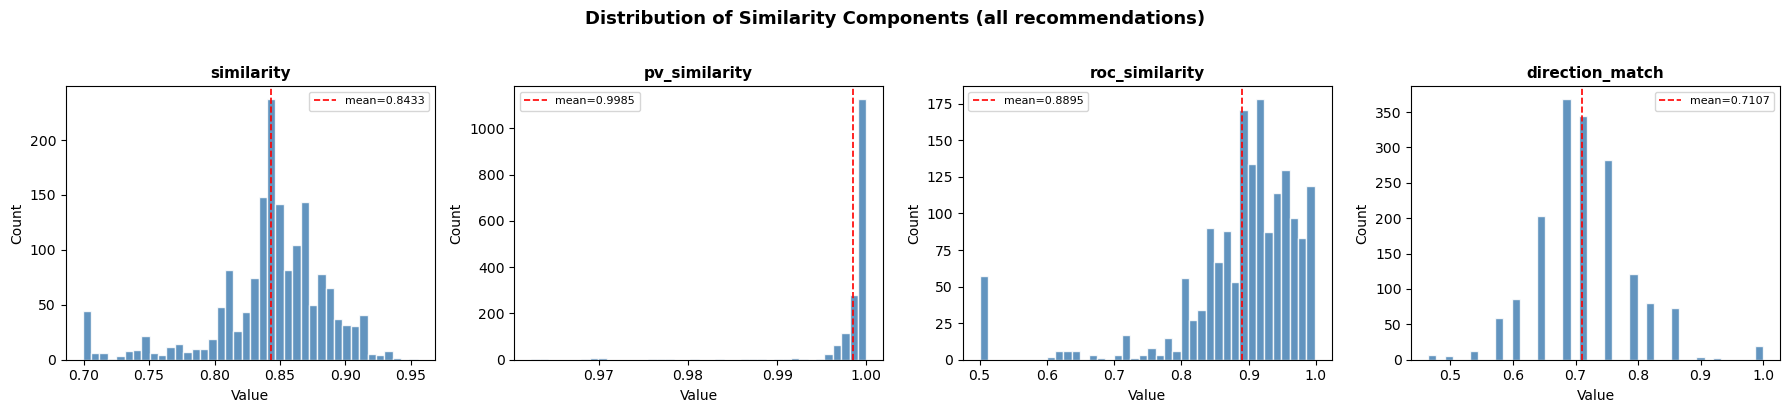


⚠️  PV similarity is nearly 1.0 for almost all rows — it contributes almost no discriminative power.


In [3]:
# ---------- Distribution of similarity components ----------
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, sim_cols):
    vals = recs_df[col].dropna()
    ax.hist(vals, bins=40, edgecolor='white', alpha=0.85, color='steelblue')
    ax.axvline(vals.mean(), color='red', ls='--', lw=1.2, label=f'mean={vals.mean():.4f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Similarity Components (all recommendations)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  PV similarity is nearly 1.0 for almost all rows — it contributes almost no discriminative power.")

## 2. Same-Minute Action Redundancy

Since PV data is **minute-wise**, multiple operator actions within the same minute produce **identical PV context** and therefore **identical recommendations**. This inflates apparent performance metrics and hides where the model actually has discriminative ability.

In [4]:
# ---------- Same-minute analysis on ACTUAL actions ----------
actuals_df['minute'] = actuals_df['actual_action_time'].dt.floor('min')
actuals_df['is_same_minute'] = actuals_df.groupby(['episode_id', 'minute'])['action_group'].transform('count') > 1

n_total  = len(actuals_df)
n_same   = actuals_df['is_same_minute'].sum()
n_unique = n_total - n_same

print("=== Same-Minute Redundancy (Actual Operator Actions) ===\n")
print(f"Total actual actions:             {n_total}")
print(f"Actions sharing a minute:         {n_same}  ({100*n_same/n_total:.1f}%)")
print(f"Actions with unique minute:       {n_unique}  ({100*n_unique/n_total:.1f}%)")
print()

# For same-minute groups, check if the recommendations (from their action_group) are identical
same_min_groups = actuals_df[actuals_df['is_same_minute']].groupby(['episode_id', 'minute'])

# For each same-minute group of actuals, get rank-1 recs and check if identical
identical_count = 0
for (ep, minute), grp in same_min_groups:
    # Get rank-1 recs for these action_groups
    action_groups = grp['action_group'].values
    group_recs = recs_df[(recs_df['episode_id'] == ep) & (recs_df['action_group'].isin(action_groups))]
    # Take first rec per action_group (they are ordered by similarity)
    first_recs = group_recs.drop_duplicates(subset=['action_group'], keep='first')
    unique_recs = first_recs[['source', 'direction', 'magnitude']].drop_duplicates()
    if len(unique_recs) == 1:
        identical_count += 1

print(f"Same-minute groups with identical top-1 rec: {identical_count}/{same_min_groups.ngroups} "
      f"({100*identical_count/same_min_groups.ngroups:.0f}%)")

=== Same-Minute Redundancy (Actual Operator Actions) ===

Total actual actions:             555
Actions sharing a minute:         412  (74.2%)
Actions with unique minute:       143  (25.8%)

Same-minute groups with identical top-1 rec: 66/66 (100%)


In [5]:
# ---------- Per-episode same-minute breakdown ----------
episode_stats = []
for ep_id, ep_df in actuals_df.groupby('episode_id'):
    n_actions = len(ep_df)
    n_minutes = ep_df['minute'].nunique()
    n_same_min = ep_df['is_same_minute'].sum()
    episode_stats.append({
        'episode_id': ep_id,
        'total_actions': n_actions,
        'unique_minutes': n_minutes,
        'same_minute_actions': n_same_min,
        'same_minute_pct': round(100 * n_same_min / n_actions, 1) if n_actions else 0
    })

ep_stats_df = pd.DataFrame(episode_stats).sort_values('same_minute_pct', ascending=False)

print("=== Per-Episode Same-Minute Redundancy (Actual Actions) ===\n")
print(ep_stats_df.to_string(index=False))
print(f"\nEpisodes with >50% same-minute actions: {(ep_stats_df['same_minute_pct'] > 50).sum()}/{len(ep_stats_df)}")

=== Per-Episode Same-Minute Redundancy (Actual Actions) ===

 episode_id  total_actions  unique_minutes  same_minute_actions  same_minute_pct
        546              2               1                    2            100.0
        587             33               4                   33            100.0
        596              4               2                    4            100.0
        586             78               7                   78            100.0
        583             54               5                   53             98.1
        585             54               5                   53             98.1
        584             54               5                   53             98.1
        601             36               5                   34             94.4
        548              9               4                    7             77.8
        567             46              23                   33             71.7
        556              3               2      

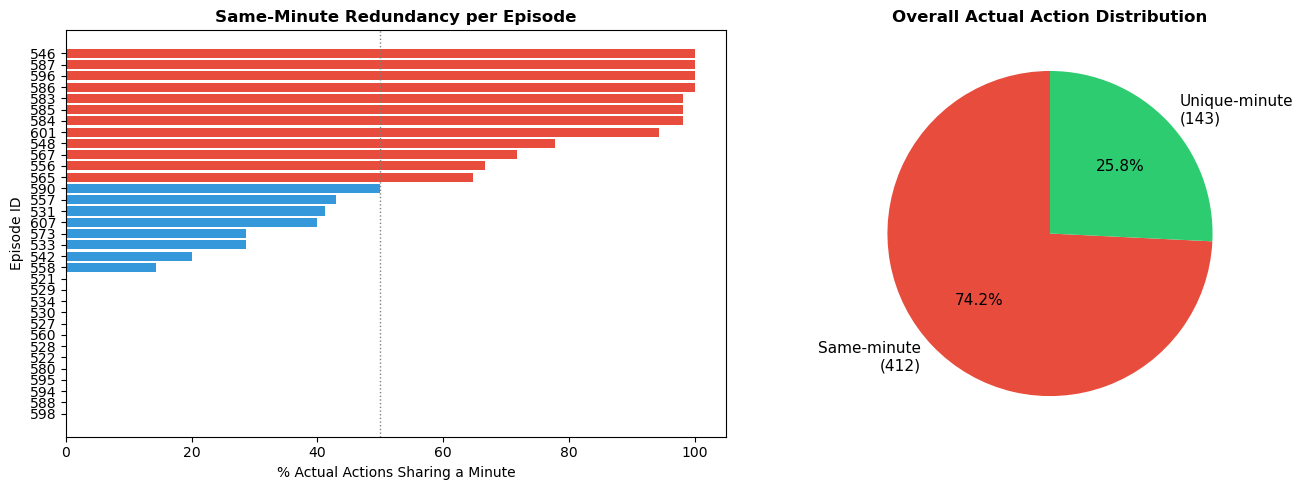

In [6]:
# ---------- Visualize same-minute problem ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: per-episode same-minute %
ax = axes[0]
colors = ['#e74c3c' if p > 50 else '#3498db' for p in ep_stats_df['same_minute_pct']]
ax.barh(ep_stats_df['episode_id'].astype(str), ep_stats_df['same_minute_pct'], color=colors)
ax.set_xlabel('% Actual Actions Sharing a Minute')
ax.set_ylabel('Episode ID')
ax.set_title('Same-Minute Redundancy per Episode', fontweight='bold')
ax.axvline(50, color='gray', ls=':', lw=1)
ax.invert_yaxis()

# Pie: overall split
ax = axes[1]
ax.pie([n_same, n_unique],
       labels=[f'Same-minute\n({n_same})', f'Unique-minute\n({n_unique})'],
       colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 11})
ax.set_title('Overall Actual Action Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Accuracy Metrics – All Actions vs. Deduplicated (Unique-Minute)

We compute accuracy two ways:
- **All actions**: every action row evaluated (inflated by same-minute duplicates)
- **Deduplicated**: keep only **one action per episode-minute** (the first), removing redundant copies that share identical PV context

In [7]:
# ---------- Accuracy: build per-action evaluation using the match columns ----------
# Each action_group has 1 actual + 3 recommended rows.
# The recommended rows already have pre-computed match columns:
#   tag_match_to_actual, direction_match_to_actual, magnitude_match_to_actual

# Get top-1 recommendation per action_group (first rec row = highest similarity)
top1_recs = recs_df.drop_duplicates(subset=['episode_id', 'action_group'], keep='first').copy()

# Merge minute info from actuals
top1_recs = top1_recs.merge(
    actuals_df[['episode_id', 'action_group', 'minute', 'is_same_minute']],
    on=['episode_id', 'action_group'], how='left'
)

# Deduplicate: keep first action per episode-minute
top1_sorted = top1_recs.sort_values(['episode_id', 'minute', 'action_group'])
top1_dedup = top1_sorted.drop_duplicates(subset=['episode_id', 'minute'], keep='first')

print(f"Top-1 recs before dedup: {len(top1_recs)}")
print(f"Top-1 recs after  dedup: {len(top1_dedup)}  (removed {len(top1_recs)-len(top1_dedup)} same-minute duplicates)\n")

def compute_metrics(df, label):
    """Compute match rates using pre-computed match columns."""
    return {
        'subset': label,
        'n_actions': len(df),
        'tag_match': f"{df['tag_match_to_actual'].mean():.1%}",
        'direction_match': f"{df['direction_match_to_actual'].mean():.1%}",
        'magnitude_match': f"{df['magnitude_match_to_actual'].mean():.1%}",
        'avg_similarity': f"{df['similarity'].mean():.4f}",
        'avg_pv_similarity': f"{df['pv_similarity'].mean():.4f}",
        'avg_roc_similarity': f"{df['roc_similarity'].mean():.4f}",
    }

metrics = pd.DataFrame([
    compute_metrics(top1_recs, 'All actions (Top 1)'),
    compute_metrics(top1_dedup, 'Deduplicated (Top 1)'),
    compute_metrics(top1_recs[~top1_recs['is_same_minute']], 'Unique-minute only (Top 1)'),
    compute_metrics(top1_recs[top1_recs['is_same_minute']], 'Same-minute only (Top 1)'),
])
print("=== Accuracy Comparison ===\n")
print(metrics.to_string(index=False))

Top-1 recs before dedup: 555
Top-1 recs after  dedup: 209  (removed 346 same-minute duplicates)

=== Accuracy Comparison ===

                    subset  n_actions tag_match direction_match magnitude_match avg_similarity avg_pv_similarity avg_roc_similarity
       All actions (Top 1)        555     76.2%           53.7%           37.7%         0.8536            0.9986             0.8938
      Deduplicated (Top 1)        209     52.6%           58.4%           38.8%         0.8532            0.9978             0.8948
Unique-minute only (Top 1)        143     45.5%           58.0%           37.8%         0.8532            0.9978             0.8970
  Same-minute only (Top 1)        412     86.9%           52.2%           37.6%         0.8537            0.9989             0.8927


## 4. Accuracy Across All Ranks (Top-K Analysis)

Each action gets 3 ranked recommendations. Check if the correct tag/direction appears anywhere in top-K (deduplicated by minute).

In [8]:
# ---------- Top-K hit rates (deduplicated by minute) ----------
# Merge minute info into all recs
all_recs = recs_df.merge(
    actuals_df[['episode_id', 'action_group', 'minute']],
    on=['episode_id', 'action_group'], how='left'
)

# Deduplicate: for each (episode, minute), keep only recs from the first action_group
first_ag_per_minute = actuals_df.sort_values('action_group').drop_duplicates(
    subset=['episode_id', 'minute'], keep='first'
)[['episode_id', 'minute', 'action_group']]

recs_dedup = all_recs.merge(first_ag_per_minute, on=['episode_id', 'minute', 'action_group'])

# Assign rank within each action_group (recs are ordered by similarity)
recs_dedup['rank'] = recs_dedup.groupby(['episode_id', 'action_group']).cumcount() + 1

print(f"Deduplicated rec rows: {len(recs_dedup)}  (unique minutes x recs)")
print()

topk_metrics = []
for k in [1, 2, 3]:
    subset = recs_dedup[recs_dedup['rank'] <= k]
    grouped = subset.groupby(['episode_id', 'minute'])
    
    tag_hit = grouped['tag_match_to_actual'].max()  # 1.0 if any rec matched
    dir_hit = grouped['direction_match_to_actual'].max()
    both_hit = grouped.apply(
        lambda g: ((g['tag_match_to_actual'] == 1.0) & (g['direction_match_to_actual'] == 1.0)).any()
    )
    
    topk_metrics.append({
        'top_k': k,
        'n_unique_actions': len(grouped),
        'tag_hit_rate': f"{(tag_hit == 1.0).mean():.1%}",
        'direction_hit_rate': f"{(dir_hit == 1.0).mean():.1%}",
        'tag+direction_hit_rate': f"{both_hit.mean():.1%}",
    })

topk_df = pd.DataFrame(topk_metrics)
print("=== Top-K Hit Rates (deduplicated, one per episode-minute) ===\n")
print(topk_df.to_string(index=False))

Deduplicated rec rows: 627  (unique minutes x recs)

=== Top-K Hit Rates (deduplicated, one per episode-minute) ===

 top_k  n_unique_actions tag_hit_rate direction_hit_rate tag+direction_hit_rate
     1               209        52.6%              58.4%                  33.5%
     2               209        66.0%              74.2%                  48.8%
     3               209        73.2%              78.5%                  57.9%


## 5. Per-Episode Accuracy (Deduplicated)

How does accuracy vary across episodes? Some episodes may be consistently well-predicted while others are poor.

In [9]:
# ---------- Per-episode accuracy (top-1, deduplicated) ----------
ep_accuracy = []
for ep_id, grp in top1_dedup.groupby('episode_id'):
    n = len(grp)
    tag_m = grp['tag_match_to_actual'].mean()
    dir_m = grp['direction_match_to_actual'].mean()
    both_m = ((grp['tag_match_to_actual'] == 1.0) & (grp['direction_match_to_actual'] == 1.0)).mean()
    mag_m = grp['magnitude_match_to_actual'].mean()
    avg_sim = grp['similarity'].mean()
    avg_roc = grp['roc_similarity'].mean()
    
    ep_accuracy.append({
        'episode_id': ep_id, 'n_unique_actions': n,
        'tag_match%': round(100*tag_m, 1), 'dir_match%': round(100*dir_m, 1),
        'tag+dir_match%': round(100*both_m, 1), 'mag_match%': round(100*mag_m, 1),
        'avg_similarity': round(avg_sim, 4), 'avg_roc_sim': round(avg_roc, 4)
    })

ep_acc_df = pd.DataFrame(ep_accuracy).sort_values('tag+dir_match%', ascending=False)

print("=== Per-Episode Accuracy (Top 1, Deduplicated) ===\n")
print(ep_acc_df.to_string(index=False))

=== Per-Episode Accuracy (Top 1, Deduplicated) ===

 episode_id  n_unique_actions  tag_match%  dir_match%  tag+dir_match%  mag_match%  avg_similarity  avg_roc_sim
        522                 1       100.0       100.0           100.0       100.0          0.8378       0.9007
        595                 3       100.0       100.0           100.0       100.0          0.9140       0.9534
        556                 2       100.0       100.0           100.0       100.0          0.8628       0.9757
        601                 5       100.0       100.0           100.0        60.0          0.8990       0.9930
        596                 2       100.0       100.0           100.0       100.0          0.8589       0.9203
        587                 4       100.0       100.0           100.0        75.0          0.8766       0.9409
        594                 3       100.0       100.0           100.0       100.0          0.9420       0.9592
        580                 3       100.0       100.0       

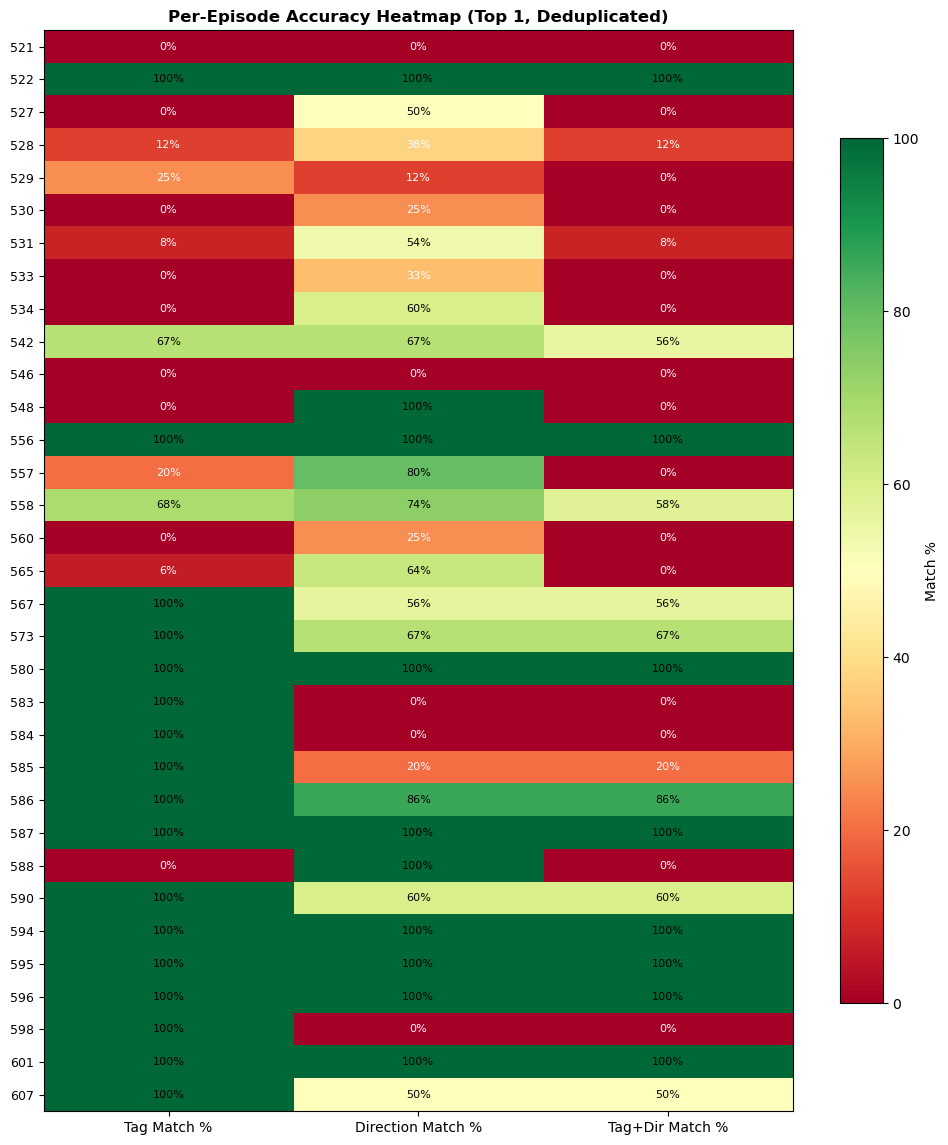

In [10]:
# ---------- Per-episode accuracy heatmap ----------
fig, ax = plt.subplots(figsize=(10, max(6, len(ep_acc_df)*0.35)))

plot_data = ep_acc_df.set_index('episode_id')[['tag_match%', 'dir_match%', 'tag+dir_match%']].copy()
plot_data = plot_data.sort_index()

im = ax.imshow(plot_data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index, fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(['Tag Match %', 'Direction Match %', 'Tag+Dir Match %'], fontsize=10)

for i in range(len(plot_data)):
    for j in range(3):
        val = plot_data.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8,
                color='white' if val < 50 else 'black')

ax.set_title('Per-Episode Accuracy Heatmap (Top 1, Deduplicated)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Match %', shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Matched-Episode Concentration

Which training episodes are being matched most frequently? High concentration on a few episodes may indicate overfitting or that only a few contexts are sufficiently similar.

=== Most Frequently Matched Training Episodes (Top 1, Deduped) ===

matched_episode_id
444.0    28
547.0    23
574.0    15
609.0    13
395.0    11
440.0     9
402.0     7
271.0     6
447.0     6
193.0     5
363.0     5
593.0     5
410.0     5
405.0     5
406.0     4

Total unique matched episodes: 43
Top-3 episodes cover: 66/209 (31.6%) of all matches


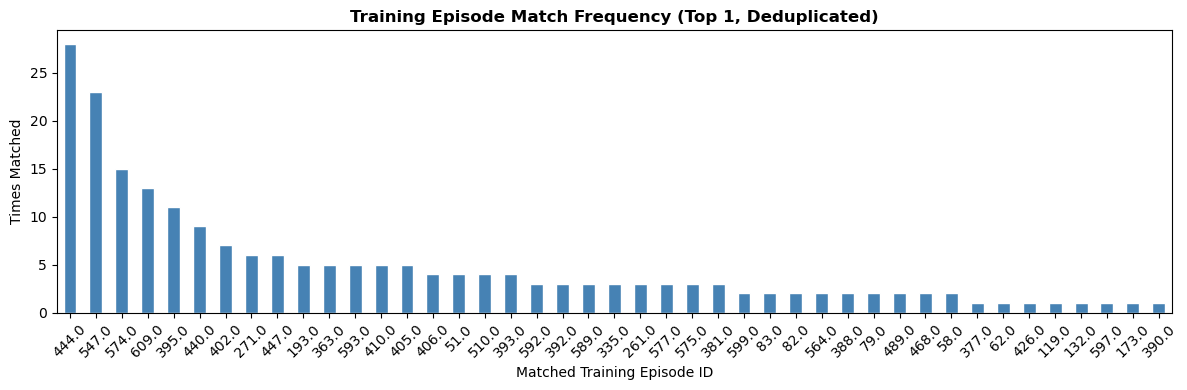

In [11]:
# ---------- Which training episodes are being matched? ----------
match_counts = top1_dedup['matched_episode_id'].value_counts()

print("=== Most Frequently Matched Training Episodes (Top 1, Deduped) ===\n")
print(match_counts.head(15).to_string())
print(f"\nTotal unique matched episodes: {match_counts.shape[0]}")
print(f"Top-3 episodes cover: {match_counts.head(3).sum()}/{match_counts.sum()} "
      f"({100*match_counts.head(3).sum()/match_counts.sum():.1f}%) of all matches")

fig, ax = plt.subplots(figsize=(12, 4))
match_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Matched Training Episode ID')
ax.set_ylabel('Times Matched')
ax.set_title('Training Episode Match Frequency (Top 1, Deduplicated)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Tag & Direction Confusion Analysis

Which tags are recommended vs what was actually operated? And where do direction errors occur?

In [12]:
# ---------- Tag confusion matrix ----------
d = top1_dedup.copy()

# Tag confusion: actual_source vs recommended source
tag_pairs = list(zip(d['actual_source'], d['source']))
all_tags = sorted(set(d['actual_source'].unique()) | set(d['source'].unique()))
tag_confusion = pd.DataFrame(0, index=all_tags, columns=all_tags)
for actual, rec in tag_pairs:
    tag_confusion.loc[actual, rec] += 1

print("=== Tag Confusion Matrix (Top 1, Deduplicated) ===")
print("  Rows = Actual tag, Columns = Recommended tag\n")
print(tag_confusion.to_string())
print()

# Direction confusion
dir_map = {0: 'Decrease', 1: 'Increase'}
d['actual_dir_label'] = d['actual_direction'].map(dir_map)
d['rec_dir_label'] = d['direction'].map(dir_map)

dir_confusion = pd.crosstab(d['actual_dir_label'], d['rec_dir_label'],
                            rownames=['Actual'], colnames=['Recommended'])
print("=== Direction Confusion Matrix ===\n")
print(dir_confusion.to_string())
print()

# Where does tag mismatch happen?
mismatches = d[d['tag_match_to_actual'] != 1.0]
print(f"Tag mismatches: {len(mismatches)}/{len(d)} ({100*len(mismatches)/len(d):.1f}%)")
if len(mismatches) > 0:
    print("\nMismatch breakdown:")
    for _, row in mismatches.iterrows():
        print(f"  Ep {row['episode_id']}: actual={row['actual_source']} rec={row['source']}  "
              f"sim={row['similarity']:.4f}  roc_sim={row['roc_similarity']:.4f}")

=== Tag Confusion Matrix (Top 1, Deduplicated) ===
  Rows = Actual tag, Columns = Recommended tag

            03LIC_1016  03LIC_1071  03PIC_1013
03LIC_1016           0           0           0
03LIC_1071           3          11          58
03PIC_1013           5          33          99

=== Direction Confusion Matrix ===

Recommended  Decrease  Increase
Actual                         
Decrease           75        47
Increase           40        47

Tag mismatches: 99/209 (47.4%)

Mismatch breakdown:
  Ep 521: actual=03LIC_1071 rec=03PIC_1013  sim=0.8931  roc_sim=0.9369
  Ep 527: actual=03LIC_1071 rec=03PIC_1013  sim=0.8812  roc_sim=0.9131
  Ep 527: actual=03LIC_1071 rec=03PIC_1013  sim=0.8156  roc_sim=0.8570
  Ep 527: actual=03LIC_1071 rec=03PIC_1013  sim=0.8079  roc_sim=0.8410
  Ep 527: actual=03LIC_1071 rec=03PIC_1013  sim=0.8772  roc_sim=0.8803
  Ep 528: actual=03LIC_1071 rec=03PIC_1013  sim=0.8578  roc_sim=0.9416
  Ep 528: actual=03LIC_1071 rec=03PIC_1013  sim=0.7769  roc_sim=0.814

## 8. Magnitude Analysis

Even when tag and direction are correct, how close is the recommended magnitude to the actual?

=== Magnitude Analysis (where tag matches, N=110) ===

Mean absolute error:   1.90
Median absolute error: 1.00
Max absolute error:    31.75



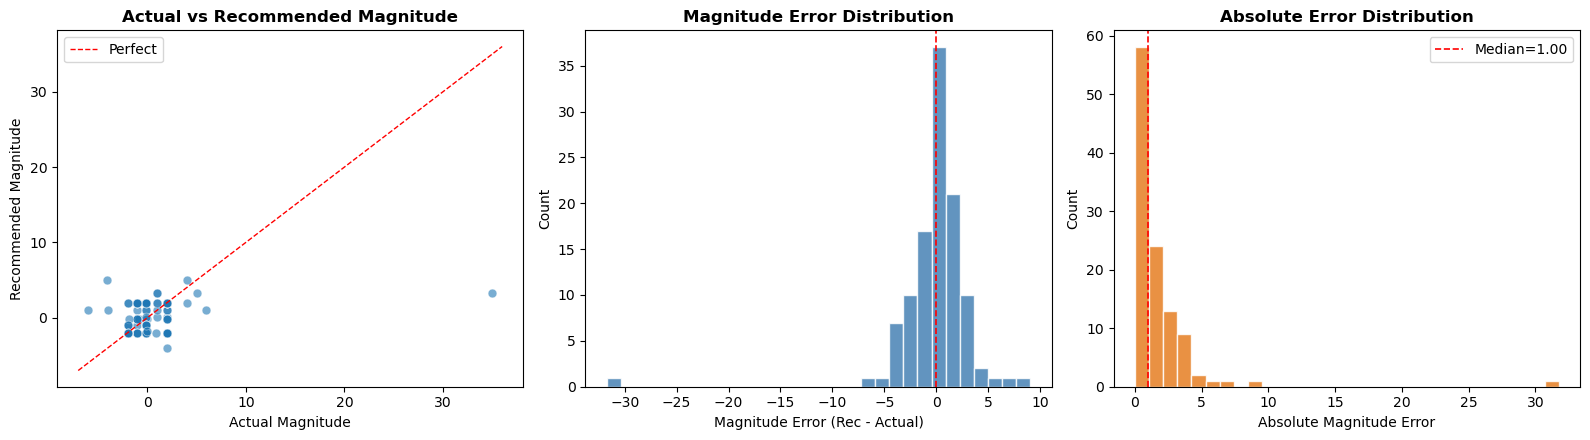

In [13]:
# ---------- Magnitude comparison (where tag matches) ----------
correct_tag = top1_dedup[top1_dedup['tag_match_to_actual'] == 1.0].copy()

# Actual magnitude from actuals_df, rec magnitude from rec's 'magnitude' column
# Merge actual magnitude
correct_tag = correct_tag.merge(
    actuals_df[['episode_id', 'action_group', 'magnitude']].rename(columns={'magnitude': 'actual_magnitude'}),
    on=['episode_id', 'action_group'], how='left'
)
correct_tag['mag_error'] = correct_tag['magnitude'] - correct_tag['actual_magnitude']
correct_tag['abs_mag_error'] = correct_tag['mag_error'].abs()

print(f"=== Magnitude Analysis (where tag matches, N={len(correct_tag)}) ===\n")
print(f"Mean absolute error:   {correct_tag['abs_mag_error'].mean():.2f}")
print(f"Median absolute error: {correct_tag['abs_mag_error'].median():.2f}")
print(f"Max absolute error:    {correct_tag['abs_mag_error'].max():.2f}")
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(correct_tag['actual_magnitude'], correct_tag['magnitude'],
           alpha=0.6, s=40, edgecolors='white', linewidths=0.5)
lims = [min(correct_tag['actual_magnitude'].min(), correct_tag['magnitude'].min()) - 1,
        max(correct_tag['actual_magnitude'].max(), correct_tag['magnitude'].max()) + 1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
ax.set_xlabel('Actual Magnitude')
ax.set_ylabel('Recommended Magnitude')
ax.set_title('Actual vs Recommended Magnitude', fontweight='bold')
ax.legend()

ax = axes[1]
ax.hist(correct_tag['mag_error'], bins=30, edgecolor='white', alpha=0.85, color='steelblue')
ax.axvline(0, color='red', ls='--', lw=1.2)
ax.set_xlabel('Magnitude Error (Rec - Actual)')
ax.set_ylabel('Count')
ax.set_title('Magnitude Error Distribution', fontweight='bold')

ax = axes[2]
ax.hist(correct_tag['abs_mag_error'], bins=30, edgecolor='white', alpha=0.85, color='#e67e22')
ax.axvline(correct_tag['abs_mag_error'].median(), color='red', ls='--', lw=1.2,
           label=f'Median={correct_tag["abs_mag_error"].median():.2f}')
ax.set_xlabel('Absolute Magnitude Error')
ax.set_ylabel('Count')
ax.set_title('Absolute Error Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Similarity Score vs Accuracy Relationship

Is higher similarity score actually predictive of a correct recommendation? And does ROC similarity matter more than overall similarity?

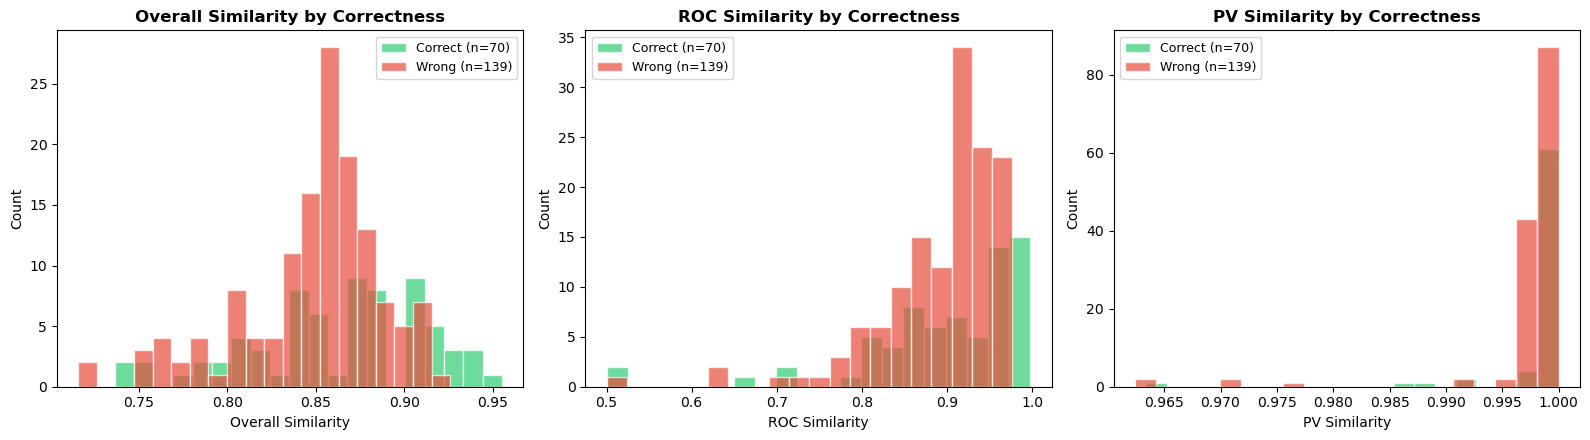

Mean similarity for correct vs wrong recommendations:

  similarity              Correct=0.8620  Wrong=0.8487  Δ=+0.0133
  roc_similarity          Correct=0.8974  Wrong=0.8936  Δ=+0.0038
  pv_similarity           Correct=0.9985  Wrong=0.9974  Δ=+0.0011


In [14]:
# ---------- Similarity vs correctness ----------
d = top1_dedup.copy()
d['both_correct'] = ((d['tag_match_to_actual'] == 1.0) & (d['direction_match_to_actual'] == 1.0)).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, sim_col, label in zip(axes,
    ['similarity', 'roc_similarity', 'pv_similarity'],
    ['Overall Similarity', 'ROC Similarity', 'PV Similarity']):
    
    correct = d[d['both_correct'] == 1][sim_col]
    wrong   = d[d['both_correct'] == 0][sim_col]
    
    ax.hist(correct, bins=20, alpha=0.7, label=f'Correct (n={len(correct)})', color='#2ecc71', edgecolor='white')
    ax.hist(wrong, bins=20, alpha=0.7, label=f'Wrong (n={len(wrong)})', color='#e74c3c', edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} by Correctness', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Mean similarity for correct vs wrong recommendations:\n")
for col in ['similarity', 'roc_similarity', 'pv_similarity']:
    c_mean = d[d['both_correct']==1][col].mean()
    w_mean = d[d['both_correct']==0][col].mean()
    print(f"  {col:22s}  Correct={c_mean:.4f}  Wrong={w_mean:.4f}  Δ={c_mean-w_mean:+.4f}")

## 10. Same-Minute Deep Dive: What the Operator Actually Did

For actions in the same minute, the operator often took **different actions** on different tags (or same tag, different direction/magnitude) — but we recommend the **same thing** for all of them. Let's look at the actual operator behaviour in these cases.

In [15]:
# ---------- Same-minute: what did the operator really do? ----------
same_min_actuals = actuals_df[actuals_df['is_same_minute']].copy()
same_min_groups = same_min_actuals.groupby(['episode_id', 'minute'])

print(f"=== Same-Minute Action Groups: {same_min_groups.ngroups} groups, {len(same_min_actuals)} total actions ===\n")

group_diversity = []
for (ep, minute), grp in same_min_groups:
    n_actions = len(grp)
    unique_actual_dirs = grp[['source', 'direction']].drop_duplicates().shape[0]
    
    group_diversity.append({
        'episode_id': ep, 'minute': minute,
        'n_actions_in_minute': n_actions,
        'unique_actual_tag_dir': unique_actual_dirs,
        'tags_operated': ', '.join(grp['source'].unique()),
    })

gd = pd.DataFrame(group_diversity)

print("Diversity of actual actions within same-minute groups:\n")
print(f"  Groups where operator did >1 distinct (tag,dir) action:  "
      f"{(gd['unique_actual_tag_dir']>1).sum()}/{len(gd)} "
      f"({100*(gd['unique_actual_tag_dir']>1).sum()/len(gd):.1f}%)")
print()

# Show examples
diverse = gd[gd['unique_actual_tag_dir'] > 1].head(8)
if len(diverse) > 0:
    print("Sample same-minute groups with diverse actual actions:\n")
    print(diverse[['episode_id','minute','n_actions_in_minute','unique_actual_tag_dir','tags_operated']].to_string(index=False))
else:
    print("All same-minute groups have the same (tag, direction) — operator does repeated small steps on same tag.")

=== Same-Minute Action Groups: 66 groups, 412 total actions ===

Diversity of actual actions within same-minute groups:

  Groups where operator did >1 distinct (tag,dir) action:  6/66 (9.1%)

Sample same-minute groups with diverse actual actions:

 episode_id              minute  n_actions_in_minute  unique_actual_tag_dir          tags_operated
        533 2025-01-08 11:46:00                    2                      2             03LIC_1071
        548 2025-01-16 10:02:00                    5                      2             03LIC_1071
        565 2025-05-09 11:01:00                    3                      2             03PIC_1013
        567 2025-05-09 11:52:00                    3                      2 03PIC_1013, 03LIC_1071
        567 2025-05-09 13:15:00                    5                      2             03PIC_1013
        590 2025-06-14 16:37:00                    4                      2             03PIC_1013


## 11. Action Type Match Analysis

Check how well the recommended action type (OP/SP) matches the actual operator action type.

In [16]:
# ---------- Action type match ----------
d = top1_dedup.copy()

# action_type_match_to_actual
at_match = d['action_type_match_to_actual'].mean()
print(f"=== Action Type Match (Top 1, Deduplicated) ===\n")
print(f"Action type match rate: {at_match:.1%}")
print()

# Crosstab of rec action_type vs actual_action_type
ct = pd.crosstab(d['actual_action_type'], d['action_type'],
                 rownames=['Actual Type'], colnames=['Recommended Type'], margins=True)
print(ct.to_string())
print()

# Combined match: tag + direction + action_type
d['all_match'] = ((d['tag_match_to_actual'] == 1.0) & 
                  (d['direction_match_to_actual'] == 1.0) & 
                  (d['action_type_match_to_actual'] == 1.0))
print(f"Tag + Direction + Action Type match: {d['all_match'].mean():.1%}")
print()

# Full match including magnitude
d['full_match'] = d['all_match'] & (d['magnitude_match_to_actual'] == 1.0)
print(f"Full match (tag + dir + type + magnitude): {d['full_match'].mean():.1%}")

=== Action Type Match (Top 1, Deduplicated) ===

Action type match rate: 85.6%

Recommended Type   OP  SP  All
Actual Type                   
OP                176  23  199
SP                  7   3   10
All               183  26  209

Tag + Direction + Action Type match: 31.6%

Full match (tag + dir + type + magnitude): 27.3%


## 12. Summary & Key Findings

In [17]:
# ---------- Final summary ----------
print("=" * 70)
print("  RESULTS ANALYSIS SUMMARY")
print("=" * 70)
print()

n_episodes = top1_dedup['episode_id'].nunique()
n_all      = len(top1_recs)
n_dedup    = len(top1_dedup)

tag_m  = top1_dedup['tag_match_to_actual'].mean()
dir_m  = top1_dedup['direction_match_to_actual'].mean()
both_m = ((top1_dedup['tag_match_to_actual'] == 1.0) & (top1_dedup['direction_match_to_actual'] == 1.0)).mean()
mag_m  = top1_dedup['magnitude_match_to_actual'].mean()

print(f"  Data source: operator_action_recommendations_by_episode.xlsx")
print(f"  Episodes tested:              {n_episodes}")
print(f"  Total actual actions:         {n_all}")
print(f"  Unique-minute actions:        {n_dedup} ({100*n_dedup/n_all:.1f}%)")
print(f"  Same-minute duplicates:       {n_all-n_dedup} ({100*(n_all-n_dedup)/n_all:.1f}%)")
print()
print(f"  --- Top-1 Accuracy (Deduplicated) ---")
print(f"  Tag match:                    {tag_m:.1%}")
print(f"  Direction match:              {dir_m:.1%}")
print(f"  Tag + Direction match:        {both_m:.1%}")
print(f"  Magnitude match:              {mag_m:.1%}")
print()
print(f"  --- Similarity Scores ---")
print(f"  PV similarity (mean):         {top1_dedup['pv_similarity'].mean():.4f}  (essentially constant)")
print(f"  ROC similarity (mean):        {top1_dedup['roc_similarity'].mean():.4f}  (main discriminator)")
print(f"  Overall similarity (mean):    {top1_dedup['similarity'].mean():.4f}")
print()
print("  --- Key Observations ---")
print(f"  1. PV similarity ~1.0 everywhere → does NOT help distinguish contexts")
print(f"  2. {100*(n_all-n_dedup)/n_all:.0f}% of actual actions share a minute → identical recs (redundant)")
print(f"  3. Only {match_counts.shape[0]} unique training episodes matched")
print(f"  4. Top-3 matched episodes cover {100*match_counts.head(3).sum()/match_counts.sum():.0f}% of all matches")
print()
print("=" * 70)

  RESULTS ANALYSIS SUMMARY

  Data source: operator_action_recommendations_by_episode.xlsx
  Episodes tested:              33
  Total actual actions:         555
  Unique-minute actions:        209 (37.7%)
  Same-minute duplicates:       346 (62.3%)

  --- Top-1 Accuracy (Deduplicated) ---
  Tag match:                    52.6%
  Direction match:              58.4%
  Tag + Direction match:        33.5%
  Magnitude match:              38.8%

  --- Similarity Scores ---
  PV similarity (mean):         0.9978  (essentially constant)
  ROC similarity (mean):        0.8948  (main discriminator)
  Overall similarity (mean):    0.8532

  --- Key Observations ---
  1. PV similarity ~1.0 everywhere → does NOT help distinguish contexts
  2. 62% of actual actions share a minute → identical recs (redundant)
  3. Only 43 unique training episodes matched
  4. Top-3 matched episodes cover 32% of all matches

